# Neural network

### Basic data model from UCI iris
https://archive.ics.uci.edu/dataset/53/iris
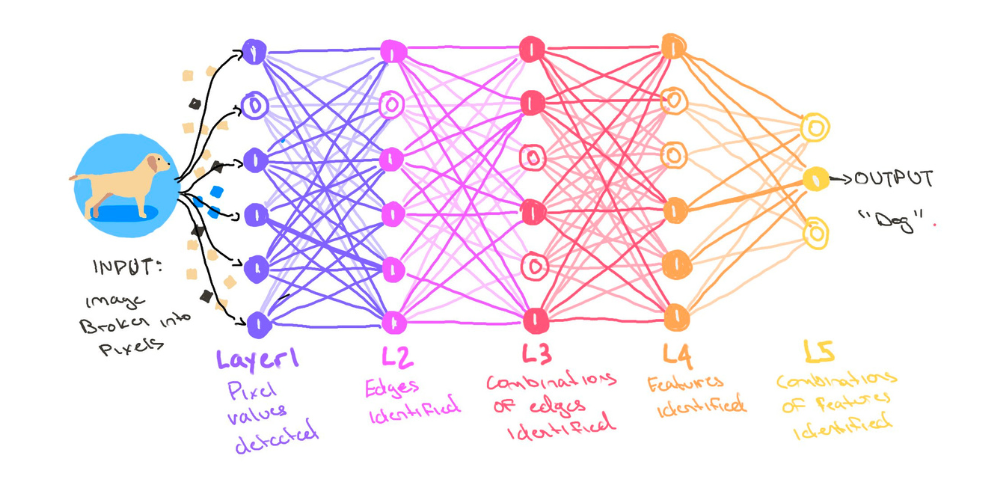
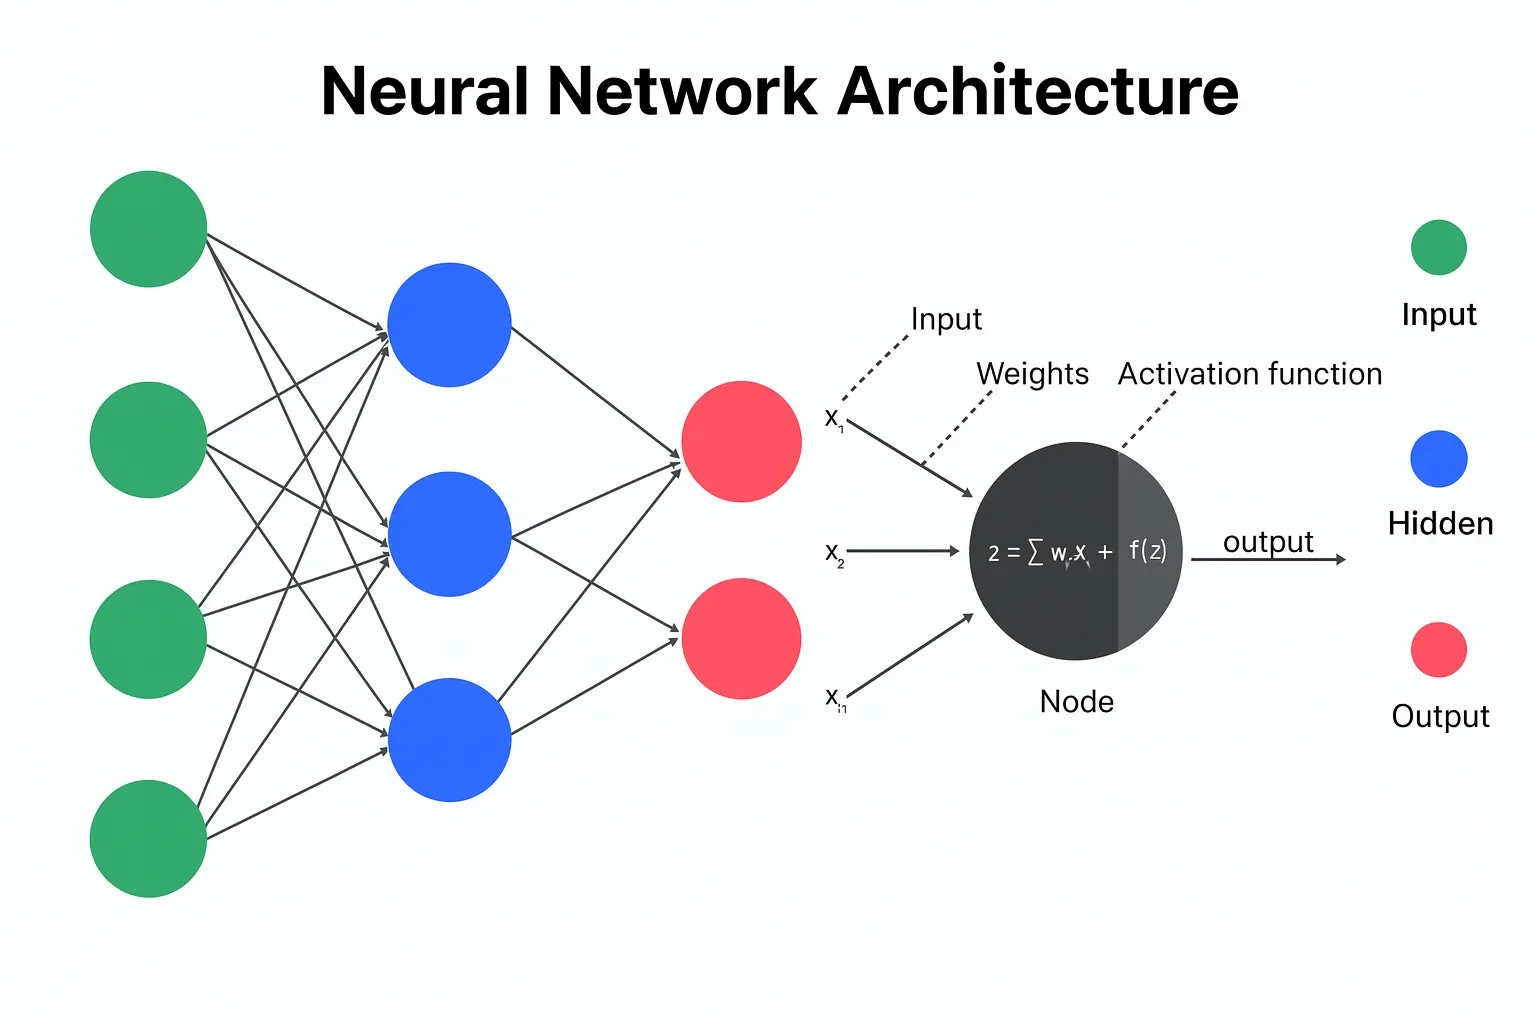
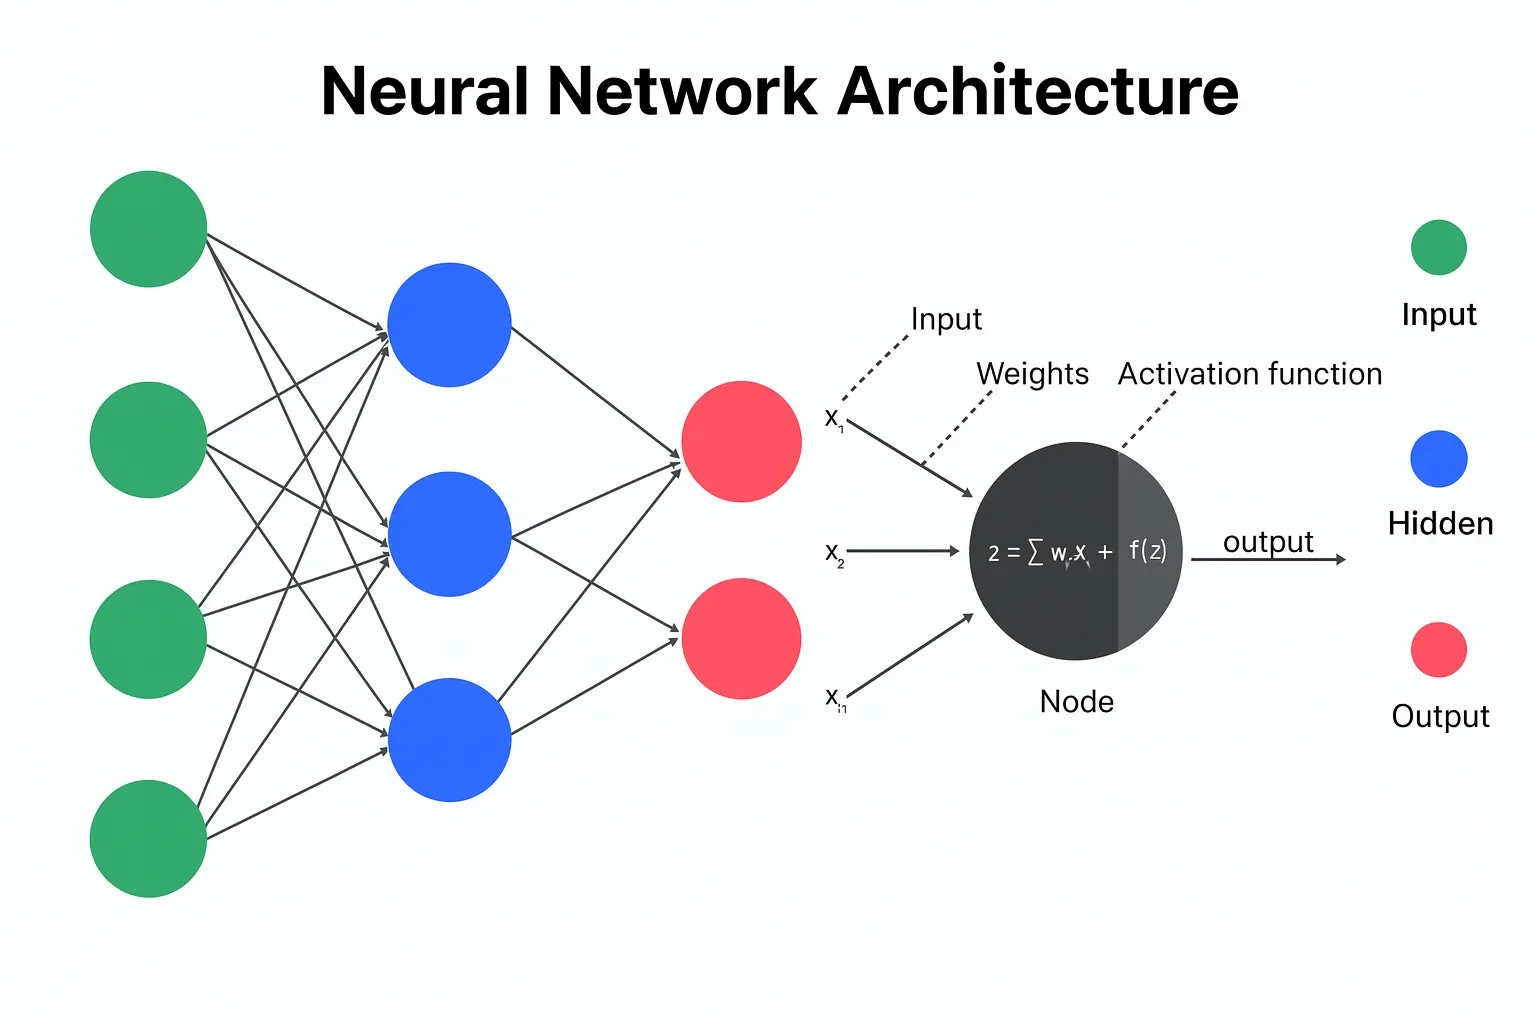
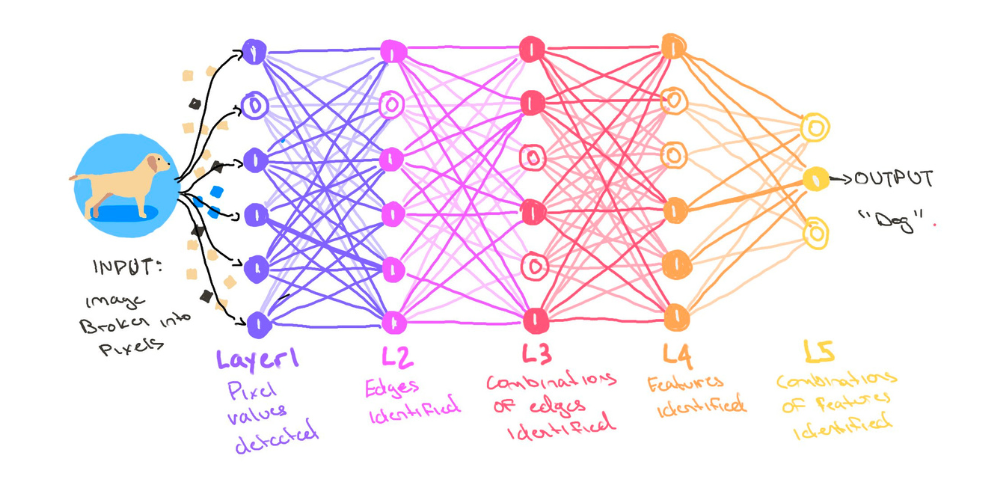

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# Create a model Class that inherits nn.Model
class Model(nn.Module):
    # input layer (4 features of the flowes) ->
    #Hiiden layer1 (no. of neurons) ->
    #H2(n) ->
    #output (3 classes of iris flowers)
    def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
        super().__init__()# instantiate our model
        self.fc1=nn.Linear(in_features,h1)
        self.fc2=nn.Linear(h1,h2)
        self.out=nn.Linear(h2,out_features)
        
    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.out(x)
        
        return x

In [3]:
# Pick a manual seed for randomization
torch.manual_seed(42)
model=Model()

### Load and Train Data

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [5]:
path="/kaggle/input/iris-data/Iris (1).csv"
my_df=pd.read_csv(path)

In [6]:
my_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
# Change last col. from string to int
my_df['Species']=my_df['Species'].replace('Iris-setosa',0.0)
my_df['Species']=my_df['Species'].replace('Iris-versicolor',1.0)
my_df['Species']=my_df['Species'].replace('Iris-virginica',2.0)
my_df

/tmp/ipykernel_55/3557610796.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['Species']=my_df['Species'].replace('Iris-virginica',2.0)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0.0
1,2,4.9,3.0,1.4,0.2,0.0
2,3,4.7,3.2,1.3,0.2,0.0
3,4,4.6,3.1,1.5,0.2,0.0
4,5,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2.0
146,147,6.3,2.5,5.0,1.9,2.0
147,148,6.5,3.0,5.2,2.0,2.0
148,149,6.2,3.4,5.4,2.3,2.0


In [8]:
# Train test split set x,y
X=my_df.drop(columns=['Id','Species']).values
Y=my_df['Species'].values

In [9]:
Y

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# Train test split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)



In [12]:
x_train=torch.FloatTensor(x_train)
x_test=torch.FloatTensor(x_test)

In [13]:
# Convet y label to tensor long
y_train=torch.LongTensor(y_train)
y_test=torch.LongTensor(y_test)

In [14]:
print("x_train shape:", x_train.shape)
print("fc1 expects:", model.fc1.in_features)


x_train shape: torch.Size([120, 4])
fc1 expects: 4


In [15]:
# Set the criterison of the model to measure the error, how far off the prediction are the actual data
criterion=nn.CrossEntropyLoss()
# Choose Adam Optimizer, lr=learing rate (if the error don't go down after a bunch of epoch so lower the lr)
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [16]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [17]:
# Train our model?
# Epoch?
epochs=100
losses=[]
for i in range(epochs):
    # Go forward and get prediction
    y_pred=model.forward(x_train)# Get preditiction

    # Measure the loss/error 
    loss=criterion(y_pred,y_train)

    # Keep the Track
    losses.append(loss.detach().numpy())

    # print every 10 epoch
    if i%10==0:
        print(f'Epoch:{i} and loss: {loss}')
    # Do some back propogation: take the error rate of forward propagation and feed it back
    # thru the network to fine tune weights

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch:0 and loss: 1.0846847295761108
Epoch:10 and loss: 0.9183797240257263
Epoch:20 and loss: 0.7622429728507996
Epoch:30 and loss: 0.6273833513259888
Epoch:40 and loss: 0.4667472541332245
Epoch:50 and loss: 0.28770601749420166
Epoch:60 and loss: 0.16738919913768768
Epoch:70 and loss: 0.10598888993263245
Epoch:80 and loss: 0.0802135244011879
Epoch:90 and loss: 0.06947019696235657


Text(0.5, 0, 'Epoch')

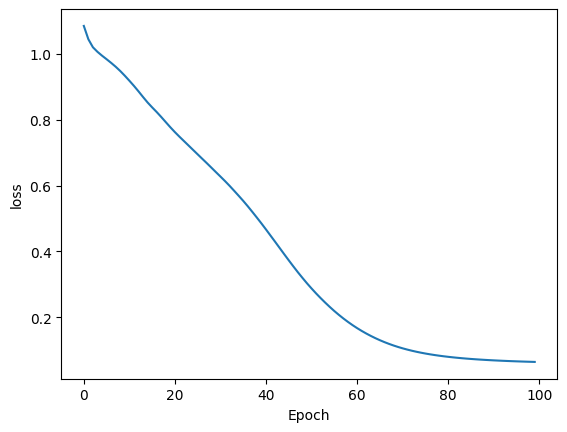

In [18]:
# graph 
plt.plot(range(epochs),losses)
plt.ylabel('loss')
plt.xlabel('Epoch')

## Evalute Model on the test Data set

In [19]:
with torch.no_grad():# Basically turn off Backpropogation
    y_eval=model.forward(x_test)
    loss=criterion(y_eval,y_test)
    


In [20]:
loss

tensor(0.0634)

In [24]:
correct=0
with torch.no_grad():
    for i,data in enumerate(x_test):
        y_val=model.forward(data)

        print(f'{i+1}.) {str(y_val)} \t {y_test[i]}')

        if y_val.argmax().item() == y_test[i]:
            correct+=1
    print(f'We got {correct} correct')

1.) tensor([-1.4120,  6.3132,  2.6088]) 	 1
2.) tensor([ 8.4023,  2.4573, -7.5391]) 	 0
3.) tensor([-12.1991,   1.1829,  13.7443]) 	 2
4.) tensor([-1.6752,  5.9271,  2.8622]) 	 1
5.) tensor([-1.5887,  6.7559,  2.8371]) 	 1
6.) tensor([ 7.8451,  2.3289, -7.0010]) 	 0
7.) tensor([ 1.1273,  6.0707, -0.0493]) 	 1
8.) tensor([-5.2088,  4.4484,  6.5316]) 	 2
9.) tensor([-3.2614,  4.9128,  4.4788]) 	 1
10.) tensor([0.5683, 6.5565, 0.5445]) 	 1
11.) tensor([-4.3492,  4.7780,  5.6344]) 	 2
12.) tensor([ 7.3631,  2.0552, -6.5497]) 	 0
13.) tensor([ 8.1384,  2.3552, -7.2879]) 	 0
14.) tensor([ 7.4936,  2.1057, -6.6740]) 	 0
15.) tensor([ 7.8643,  2.2491, -7.0269]) 	 0
16.) tensor([-1.3322,  6.5325,  2.5448]) 	 1
17.) tensor([-8.2712,  2.4244,  9.6406]) 	 2
18.) tensor([0.3374, 6.4826, 0.7657]) 	 1
19.) tensor([-1.5909,  5.7677,  2.7565]) 	 1
20.) tensor([-8.1891,  2.2739,  9.5411]) 	 2
21.) tensor([ 7.2431,  2.0816, -6.4291]) 	 0
22.) tensor([-3.9169,  4.6616,  5.1603]) 	 2
23.) tensor([ 7.3462, 

## Testing with New Data.

In [25]:
new_iris=torch.tensor([4.7,3.2,1.3,0.2])

In [26]:
with torch.no_grad():
    print(model(new_iris))

tensor([ 7.3094,  2.0344, -6.4986])
